# Lagrangian Algorithm 1 vs SNN Controller — Head-to-Head Comparison

This notebook runs **both controllers on identical inputs** and produces side-by-side
comparison plots for every major metric.

| | Lagrangian (Algorithm 1) | SNN Controller |
|---|---|---|
| **Optimiser** | Convex solver (CVXPY / SciPy) | SNNTorch LIF network + surrogate-gradient SGD |
| **Learning signal** | Lyapunov drift-plus-penalty | Differentiable net-cost loss |
| **Constraint handling** | Hard (solver enforces) | Physical clipping + QoS penalty |
| **State representation** | Raw scalars | Bernoulli rate-coded spikes |

**Paper reference:** Chen, Wang, Giannakis — *IEEE JSTSP 2016*  
**SNN framework:** [SNNTorch](https://snntorch.readthedocs.io/)


In [ ]:
import sys
!{sys.executable} -m pip install snntorch --quiet
print('Dependencies ready — restart kernel if snntorch was just installed')

Dependencies ready — restart kernel if snntorch was just installed


In [ ]:
import numpy as np
import warnings
import csv
from dataclasses import dataclass, field
from typing import List, Optional

import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

_CVXPY_AVAILABLE = False
from scipy.optimize import minimize
print("Using SciPy solver")

print(f'PyTorch  : {torch.__version__}')
print(f'SNNTorch : {snn.__version__}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device   : {DEVICE}')

plt.rcParams.update({
    'figure.dpi':      150,
    'font.size':       10,
    'axes.grid':       True,
    'grid.alpha':      0.3,
    'lines.linewidth': 1.5,
})

Using SciPy solver
PyTorch  : 2.9.1
SNNTorch : 0.9.4
Device   : cpu


In [ ]:
@dataclass
class BatteryParams:
    C_min:  float
    C_max:  float
    C_init: float
    P_min:  float   # negative → max discharge
    P_max:  float   # positive → max charge

@dataclass
class DataCenterParams:
    D_IT:               float
    num_must_serve:     int
    num_delay_tolerant: int
    MP:                 np.ndarray
    eta:                float
    revenue_per_unit:   np.ndarray
    kappa1:   float
    kappa2:   float
    T_RA:     float
    T_OA:     float
    d_OA_max: float
    P_c_max:  float
    rho:      float
    batteries: List[BatteryParams] = field(default_factory=list)

In [ ]:
def cooling_power(d: float, params: DataCenterParams) -> float:
    """Optimal combined cooling power f(d) — Eq. 8."""
    d_s = min(params.d_OA_max, (params.kappa2 / (3.0 * params.kappa1)) ** 0.5)
    if d <= d_s:
        return params.kappa1 * d ** 3
    return params.kappa1 * d_s ** 3 + params.kappa2 * (d - d_s)

def compute_net_cost(w, p_b, P_c, v_check, r,
                     alpha_c, alpha_b, alpha_s, params) -> float:
    """Operational net-cost Ψ(xᵗ) = C(·) − R(·) — Eq. 21."""
    d     = float(np.sum(v_check) + np.sum(w))
    f_d   = cooling_power(d, params)
    P_out = d + f_d + float(np.sum(p_b[p_b > 0]))
    P_in  = P_c + r  - float(np.sum(p_b[p_b < 0]))
    C = (alpha_c * P_c
         + alpha_b * max(P_out - P_in, 0.0)
         - alpha_s * max(P_in - P_out, 0.0))
    R = float(np.dot(params.revenue_per_unit, w))
    return C - R

In [ ]:
class LagrangianController:
    """Online Power and Workload Management — Algorithm 1 (Chen et al., 2016)"""

    def __init__(self, params: DataCenterParams,
                 mu: Optional[float] = None):
        self.params = params
        self.N = len(params.batteries)
        self.J = params.num_delay_tolerant
        self.mu_bar = 1e-3
        self.mu     = mu if mu is not None else self.mu_bar
        self.lambda_hat = np.zeros(self.N)
        self.nu_hat     = np.zeros(self.J)
        self._initialized = False
        self.t = 0
        self.history: List[dict] = []

    def set_price_bounds(self, alpha_b_max: float, alpha_s_min: float):
        bats = self.params.batteries
        denom = min(b.C_max - b.C_min + b.P_min - b.P_max for b in bats) if bats else 1.0
        self.mu_bar = (alpha_b_max - alpha_s_min) / abs(denom)
        self.mu = self.mu_bar
        for n, bat in enumerate(bats):
            self.lambda_hat[n] = (
                self.mu * (bat.C_init - bat.C_min + bat.P_min) - alpha_b_max)
        self._initialized = True

    def _solve_scipy(self, v_check, w_check, r,
                     alpha_c, alpha_b, alpha_s, P_c_prev):
        params, N, J = self.params, self.N, self.J
        def unpack(x): return x[:J], x[J:J+N], x[J+N]
        def objective(x):
            w, p_b, P_c = unpack(x)
            d    = float(np.sum(v_check)) + float(np.sum(w))
            f_d  = cooling_power(d, params)
            P_out = d + f_d + np.sum(p_b[p_b > 0])
            P_in  = P_c + r  - np.sum(p_b[p_b < 0])
            dm = (alpha_b - alpha_s) / 2.0
            dp = (alpha_b + alpha_s) / 2.0
            C  = dm * abs(P_out - P_in) + dp * (P_out - P_in) + alpha_c * P_c
            R  = float(np.dot(params.revenue_per_unit, w))
            bp = float(np.dot(self.lambda_hat, p_b))
            wp = float(np.sum(self.nu_hat * (
                       1.0 - params.eta - w / np.maximum(w_check, 1e-9))))
            return C - R + bp + wp
        lb, ub = [], []
        for j in range(J):   lb.append(0.0); ub.append(min(w_check[j], params.MP[j]))
        for bat in params.batteries: lb.append(bat.P_min); ub.append(bat.P_max)
        ramp = params.rho * params.P_c_max
        lb.append(max(0.0, P_c_prev - ramp)); ub.append(min(params.P_c_max, P_c_prev + ramp))
        x0  = np.array([(l + u) / 2.0 for l, u in zip(lb, ub)])
        res = minimize(objective, x0, method='L-BFGS-B', bounds=list(zip(lb, ub)),
                       options={'maxiter': 500, 'ftol': 1e-9})
        w_, p_b_, P_c_ = unpack(res.x)
        return w_, p_b_, float(P_c_)

    def _solve_cvxpy(self, v_check, w_check, r,
                     alpha_c, alpha_b, alpha_s, P_c_prev):
        params, N, J = self.params, self.N, self.J
        w   = cp.Variable(J, nonneg=True)
        p_b = cp.Variable(N)
        P_c = cp.Variable(nonneg=True)
        d   = cp.sum(v_check) + cp.sum(w)
        d_s = min(params.d_OA_max, (params.kappa2 / (3.0 * params.kappa1)) ** 0.5)
        tangents = []
        for d0 in np.linspace(0, d_s, 20):
            s = 3.0 * params.kappa1 * d0 ** 2
            tangents.append(s * d + params.kappa1 * d0**3 - s * d0)
        tangents.append(params.kappa2 * d + params.kappa1 * d_s**3 - params.kappa2 * d_s)
        f_d   = cp.maximum(*tangents)
        P_out = d + f_d + cp.sum(cp.pos(p_b))
        P_in  = P_c + r  - cp.sum(cp.neg(p_b))
        dm    = (alpha_b - alpha_s) / 2.0
        dp    = (alpha_b + alpha_s) / 2.0
        Psi   = (dm * cp.abs(P_out - P_in) + dp * (P_out - P_in)
                 + alpha_c * P_c - params.revenue_per_unit @ w)
        penalty = (self.lambda_hat @ p_b
                   + cp.sum(self.nu_hat * (
                       1.0 - params.eta - cp.multiply(w, 1.0 / np.maximum(w_check, 1e-9)))))
        ramp = params.rho * params.P_c_max
        cons = ([p_b[n] >= b.P_min for n, b in enumerate(params.batteries)]
              + [p_b[n] <= b.P_max for n, b in enumerate(params.batteries)]
              + [P_c <= params.P_c_max, P_c >= P_c_prev - ramp, P_c <= P_c_prev + ramp]
              + [w[j] <= min(w_check[j], params.MP[j]) for j in range(J)]
              + [d >= 0, d <= params.D_IT])
        prob = cp.Problem(cp.Minimize(Psi + penalty), cons)
        prob.solve(solver=cp.CLARABEL, warm_start=True)
        if prob.status not in ('optimal', 'optimal_inaccurate'):
            warnings.warn(f'CVXPY: {prob.status} — returning zeros')
            return np.zeros(J), np.zeros(N), 0.0
        return np.array(w.value), np.array(p_b.value), float(P_c.value)

    def _update_multipliers(self, p_b, w, w_check):
        self.lambda_hat += self.mu * p_b
        ratio = w / np.maximum(w_check, 1e-9)
        self.nu_hat = np.maximum(
            self.nu_hat + self.mu * (1.0 - self.params.eta - ratio), 0.0)

    def step(self, v_check, w_check, r,
             alpha_c, alpha_b, alpha_s, P_c_prev=0.0) -> dict:
        if not self._initialized:
            for n, bat in enumerate(self.params.batteries):
                self.lambda_hat[n] = (
                    self.mu * (bat.C_init - bat.C_min + bat.P_min) - alpha_b)
            self._initialized = True
        solver = self._solve_cvxpy if _CVXPY_AVAILABLE else self._solve_scipy
        w, p_b, P_c = solver(v_check, w_check, r, alpha_c, alpha_b, alpha_s, P_c_prev)
        self._update_multipliers(p_b, w, w_check)
        d   = float(np.sum(v_check) + np.sum(w))
        f_d = cooling_power(d, self.params)
        cost = compute_net_cost(w, p_b, P_c, v_check, r,
                                alpha_c, alpha_b, alpha_s, self.params)
        result = dict(t=self.t, w=w, p_b=p_b, P_c=P_c,
                      d=d, f_d=f_d, net_cost=cost,
                      lambda_hat=self.lambda_hat.copy(),
                      nu_hat=self.nu_hat.copy())
        self.history.append(result)
        self.t += 1
        return result

In [ ]:
NUM_STEPS = 25
BETA      = 0.9
HIDDEN    = 128
spike_grad = surrogate.fast_sigmoid(slope=25)

class SNNNet(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, hidden: int = HIDDEN):
        super().__init__()
        self.fc1    = nn.Linear(in_dim, hidden)
        self.lif1   = snn.Leaky(beta=BETA, spike_grad=spike_grad)
        self.fc2    = nn.Linear(hidden, hidden)
        self.lif2   = snn.Leaky(beta=BETA, spike_grad=spike_grad)
        self.fc_out = nn.Linear(hidden, out_dim)
        self.lif_out = snn.Leaky(beta=BETA, spike_grad=spike_grad)

    def forward(self, x_spikes: torch.Tensor):
        """x_spikes: (NUM_STEPS, batch, in_dim) → mean spike rate (batch, out_dim)"""
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem_out = self.lif_out.init_leaky()
        spike_acc = torch.zeros(x_spikes.shape[1],
                                self.fc_out.out_features,
                                device=x_spikes.device)
        for t in range(x_spikes.shape[0]):
            spk1, mem1   = self.lif1(self.fc1(x_spikes[t]), mem1)
            spk2, mem2   = self.lif2(self.fc2(spk1), mem2)
            spk_out, mem_out = self.lif_out(self.fc_out(spk2), mem_out)
            spike_acc += spk_out
        return spike_acc / NUM_STEPS

In [ ]:
class FeatureNormaliser:
    def __init__(self, dim: int, eps: float = 1e-6):
        self.lo  = np.full(dim,  np.inf)
        self.hi  = np.full(dim, -np.inf)
        self.eps = eps

    def update_and_normalise(self, x: np.ndarray) -> np.ndarray:
        self.lo = np.minimum(self.lo, x)
        self.hi = np.maximum(self.hi, x)
        rng = np.where(self.hi - self.lo > self.eps, self.hi - self.lo, self.eps)
        return np.clip((x - self.lo) / rng, 0.0, 1.0)

def rate_encode(norm_vec, num_steps, device):
    p = torch.tensor(norm_vec, dtype=torch.float32, device=device).unsqueeze(0)
    return torch.bernoulli(p.expand(num_steps, -1, -1))

def decode_actions(rate, v_check, w_check, soc, P_c_prev, params):
    J = params.num_delay_tolerant
    N = len(params.batteries)
    r = rate.squeeze(0).detach().cpu().numpy()
    w = np.array([r[j] * min(w_check[j], params.MP[j]) for j in range(J)])
    p_b = np.array([
        np.clip(
            r[J+n] * (params.batteries[n].P_max - params.batteries[n].P_min)
            + params.batteries[n].P_min,
            max(params.batteries[n].P_min, params.batteries[n].C_min - soc[n]),
            min(params.batteries[n].P_max, params.batteries[n].C_max - soc[n])
        ) for n in range(N)
    ])
    ramp   = params.rho * params.P_c_max
    P_c_lo = max(0.0, P_c_prev - ramp)
    P_c_hi = min(params.P_c_max, P_c_prev + ramp)
    P_c    = float(r[J+N] * (P_c_hi - P_c_lo) + P_c_lo)
    return w, p_b, P_c

In [ ]:
class SNNController:
    def __init__(self, params: DataCenterParams,
                 lr: float = 3e-4, num_steps: int = NUM_STEPS,
                 device: torch.device = DEVICE):
        self.params    = params
        self.num_steps = num_steps
        self.device    = device
        self.J = params.num_delay_tolerant
        self.N = len(params.batteries)
        self.I = params.num_must_serve
        in_dim  = 4 + self.I + self.J + self.N + 1
        out_dim = self.J + self.N + 1
        self.net       = SNNNet(in_dim, out_dim).to(device)
        self.optimiser = torch.optim.Adam(self.net.parameters(), lr=lr)
        self.normaliser = FeatureNormaliser(in_dim)
        self.soc = np.array([b.C_init for b in params.batteries], dtype=float)
        self.t   = 0
        self.history: list = []

    def _build_state(self, v_check, w_check, r, alpha_c, alpha_b, alpha_s, P_c_prev):
        return np.concatenate([[r, alpha_b, alpha_s, alpha_c],
                               v_check, w_check, self.soc, [P_c_prev]])

    def _differentiable_cost(self, rate, v_check_t, w_check_np,
                             r_val, alpha_c, alpha_b, alpha_s, P_c_prev):
        J, N = self.J, self.N
        r_out = rate.squeeze(0)
        w_max = torch.tensor([min(w_check_np[j], self.params.MP[j]) for j in range(J)],
                             dtype=torch.float32, device=self.device)
        w_t   = r_out[:J] * w_max
        p_min_t = torch.tensor([b.P_min for b in self.params.batteries],
                               dtype=torch.float32, device=self.device)
        p_rng_t = torch.tensor([b.P_max - b.P_min for b in self.params.batteries],
                               dtype=torch.float32, device=self.device)
        p_b_t = r_out[J:J+N] * p_rng_t + p_min_t
        ramp   = self.params.rho * self.params.P_c_max
        P_c_lo = max(0.0, P_c_prev - ramp)
        P_c_hi = min(self.params.P_c_max, P_c_prev + ramp)
        P_c_t  = r_out[J+N] * (P_c_hi - P_c_lo) + P_c_lo
        d_t    = v_check_t.sum() + w_t.sum()
        d_s    = min(self.params.d_OA_max,
                    (self.params.kappa2 / (3.0 * self.params.kappa1)) ** 0.5)
        f_d_t  = torch.where(
            d_t <= d_s,
            self.params.kappa1 * d_t ** 3,
            torch.tensor(self.params.kappa1 * d_s**3, device=self.device)
            + self.params.kappa2 * (d_t - d_s))
        P_out  = d_t + f_d_t + torch.clamp(p_b_t, min=0.0).sum()
        P_in   = P_c_t + r_val - torch.clamp(p_b_t, max=0.0).abs().sum()
        net_flow = P_out - P_in
        buying   = torch.clamp(net_flow,  min=0.0) * alpha_b
        selling  = torch.clamp(-net_flow, min=0.0) * alpha_s
        cg_cost  = P_c_t * alpha_c
        rev_t    = torch.tensor(self.params.revenue_per_unit,
                               dtype=torch.float32, device=self.device)
        revenue  = (rev_t * w_t).sum()
        qos_target = torch.tensor([(1.0 - self.params.eta) * w_check_np[j]
                                   for j in range(J)],
                                  dtype=torch.float32, device=self.device)
        qos_penalty = torch.clamp(qos_target - w_t, min=0.0).sum() * 10.0
        return buying - selling + cg_cost - revenue + qos_penalty

    def step(self, v_check, w_check, r,
             alpha_c, alpha_b, alpha_s, P_c_prev=0.0) -> dict:
        state_norm = self.normaliser.update_and_normalise(
            self._build_state(v_check, w_check, r, alpha_c, alpha_b, alpha_s, P_c_prev))
        spikes = rate_encode(state_norm, self.num_steps, self.device)
        self.net.train()
        self.optimiser.zero_grad()
        rate = self.net(spikes)
        v_t  = torch.tensor(v_check, dtype=torch.float32, device=self.device)
        loss = self._differentiable_cost(rate, v_t, w_check, r,
                                         alpha_c, alpha_b, alpha_s, P_c_prev)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.net.parameters(), max_norm=1.0)
        self.optimiser.step()
        with torch.no_grad():
            rate_np = self.net(spikes)
        w, p_b, P_c = decode_actions(rate_np, v_check, w_check,
                                      self.soc, P_c_prev, self.params)
        for n, bat in enumerate(self.params.batteries):
            self.soc[n] = np.clip(self.soc[n] + p_b[n], bat.C_min, bat.C_max)
        d    = float(np.sum(v_check) + np.sum(w))
        f_d  = cooling_power(d, self.params)
        cost = compute_net_cost(w, p_b, P_c, v_check, r,
                                alpha_c, alpha_b, alpha_s, self.params)
        result = dict(t=self.t, w=w, p_b=p_b, P_c=P_c,
                      d=d, f_d=f_d, net_cost=cost,
                      soc=self.soc.copy(),
                      train_loss=float(loss.item()))
        self.history.append(result)
        self.t += 1
        return result

In [ ]:
batteries = [
    BatteryParams(C_min=5, C_max=50, C_init=5, P_min=-5, P_max=5),
    BatteryParams(C_min=5, C_max=50, C_init=5, P_min=-5, P_max=5),
]
params = DataCenterParams(
    D_IT               = 100,
    num_must_serve     = 3,
    num_delay_tolerant = 5,
    MP                 = np.full(5, 15.0),
    eta                = 0.2,
    revenue_per_unit   = np.ones(5) * 0.5,
    kappa1             = 1e-10,
    kappa2             = 0.2,
    T_RA               = 35.0,
    T_OA               = 20.0,
    d_OA_max           = 30.0,
    P_c_max            = 50.0,
    rho                = 0.6,
    batteries          = batteries,
)

In [10]:
# =============================================================================
# CELL 9 — Load PJM wind CSV  ← update CSV_PATH
# =============================================================================
CSV_PATH = "../datasets/pjm_wind_forecast_hourly_17feb_5march.csv"
SCALE    = 0.001

with open(CSV_PATH, newline='') as f:
    rows = list(csv.DictReader(f))

r_seq = np.array([float(row['wind_forecast']) for row in rows]) * SCALE
T     = len(r_seq)
print(f'Loaded {T} slots | min={r_seq.min():.2f}  max={r_seq.max():.2f}  mean={r_seq.mean():.2f} kWh/slot')

Loaded 336 slots | min=0.44  max=9.63  mean=4.49 kWh/slot


In [ ]:
rng = np.random.default_rng(42)
I, J = 3, 5

v_check_seq = rng.poisson(10, size=(T, I)).astype(float)
w_check_seq = rng.poisson(5,  size=(T, J)).astype(float)
alpha_b_seq = rng.uniform(50, 100, size=T)
alpha_s_seq = 0.8 * alpha_b_seq
alpha_c_seq = np.full(T, alpha_b_seq.mean())

print('Shared input sequences generated with seed=42')
print('Both controllers will receive IDENTICAL inputs — ensuring a fair comparison')

Shared input sequences generated with seed=42
Both controllers will receive IDENTICAL inputs — ensuring a fair comparison


In [ ]:
print('Running Lagrangian controller (Algorithm 1)...')
lag_ctrl = LagrangianController(params)
lag_ctrl.set_price_bounds(alpha_b_max=100.0, alpha_s_min=40.0)
print(f'  μ = {lag_ctrl.mu:.5f}  (μ_bar = {lag_ctrl.mu_bar:.5f})')

lag_costs, lag_records, P_c_prev = [], [], 0.0

for t in range(T):
    res = lag_ctrl.step(
        v_check=v_check_seq[t], w_check=w_check_seq[t], r=r_seq[t],
        alpha_c=alpha_c_seq[t], alpha_b=alpha_b_seq[t],
        alpha_s=alpha_s_seq[t], P_c_prev=P_c_prev,
    )
    P_c_prev = res['P_c']
    lag_costs.append(res['net_cost'])
    lag_records.append({
        't': t, 'r_kWh': r_seq[t], 'alpha_b': alpha_b_seq[t],
        'd': res['d'], 'f_d': res['f_d'], 'P_c': res['P_c'],
        **{f'p_b_{n}': float(res['p_b'][n]) for n in range(2)},
        **{f'w_{j}':   float(res['w'][j])   for j in range(5)},
        'net_cost': res['net_cost'],
        'lambda_hat_0': float(res['lambda_hat'][0]),
    })
    if (t + 1) % 50 == 0:
        print(f'  Lag  t={t+1:4d}/{T}  avg_cost={np.mean(lag_costs):.2f}')

lag_avg_costs = np.cumsum(lag_costs) / np.arange(1, T + 1)
print(f'\nLagrangian done. Final avg net-cost: {lag_avg_costs[-1]:.2f} $/slot')

Running Lagrangian controller (Algorithm 1)...
  μ = 1.71429  (μ_bar = 1.71429)
  Lag  t=  50/336  avg_cost=1650.60
  Lag  t= 100/336  avg_cost=1607.49
  Lag  t= 150/336  avg_cost=1619.06
  Lag  t= 200/336  avg_cost=1680.39
  Lag  t= 250/336  avg_cost=1756.08
  Lag  t= 300/336  avg_cost=1826.50

Lagrangian done. Final avg net-cost: 1884.79 $/slot


In [ ]:
print('Running SNN controller...')
snn_ctrl = SNNController(params, lr=3e-4, num_steps=NUM_STEPS, device=DEVICE)
print(f'  SNN parameters: {sum(p.numel() for p in snn_ctrl.net.parameters()):,}')

snn_costs, snn_records, P_c_prev = [], [], 0.0

for t in range(T):
    res = snn_ctrl.step(
        v_check=v_check_seq[t], w_check=w_check_seq[t], r=r_seq[t],
        alpha_c=alpha_c_seq[t], alpha_b=alpha_b_seq[t],
        alpha_s=alpha_s_seq[t], P_c_prev=P_c_prev,
    )
    P_c_prev = res['P_c']
    snn_costs.append(res['net_cost'])
    snn_records.append({
        't': t, 'r_kWh': r_seq[t], 'alpha_b': alpha_b_seq[t],
        'd': res['d'], 'f_d': res['f_d'], 'P_c': res['P_c'],
        **{f'p_b_{n}': float(res['p_b'][n]) for n in range(2)},
        **{f'w_{j}':   float(res['w'][j])   for j in range(5)},
        'net_cost': res['net_cost'],
        'train_loss': res['train_loss'],
        **{f'soc_{n}': float(res['soc'][n]) for n in range(2)},
    })
    if (t + 1) % 50 == 0:
        print(f'  SNN  t={t+1:4d}/{T}  avg_cost={np.mean(snn_costs):.2f}  '
              f'loss={res["train_loss"]:.3f}')

snn_avg_costs = np.cumsum(snn_costs) / np.arange(1, T + 1)
print(f'\nSNN done. Final avg net-cost: {snn_avg_costs[-1]:.2f} $/slot')

Running SNN controller...
  SNN parameters: 19,592
  SNN  t=  50/336  avg_cost=1765.26  loss=3154.837
  SNN  t= 100/336  avg_cost=1761.17  loss=2992.531
  SNN  t= 150/336  avg_cost=1768.74  loss=1519.945
  SNN  t= 200/336  avg_cost=1816.63  loss=2307.308
  SNN  t= 250/336  avg_cost=1863.91  loss=3531.509
  SNN  t= 300/336  avg_cost=1872.53  loss=3481.299

SNN done. Final avg net-cost: 1904.68 $/slot


In [ ]:
lag_d    = [r['d']   for r in lag_records]
snn_d    = [r['d']   for r in snn_records]
lag_f_d  = [r['f_d'] for r in lag_records]
snn_f_d  = [r['f_d'] for r in snn_records]
lag_P_c  = [r['P_c'] for r in lag_records]
snn_P_c  = [r['P_c'] for r in snn_records]

t_arr = np.arange(T)

print(f'{"="*62}')
print(f'  Metric                    Lagrangian       SNN')
print(f'{"="*62}')
print(f'  Final avg net-cost     {lag_avg_costs[-1]:>10.2f}   {snn_avg_costs[-1]:>10.2f}  $/slot')
print(f'  Total net-cost         {sum(lag_costs):>10.2f}   {sum(snn_costs):>10.2f}  $')
print(f'  Avg IT demand          {np.mean(lag_d):>10.2f}   {np.mean(snn_d):>10.2f}  kWh/slot')
print(f'  Avg cooling power      {np.mean(lag_f_d):>10.4f}   {np.mean(snn_f_d):>10.4f}  kWh/slot')
print(f'  Avg CG output          {np.mean(lag_P_c):>10.2f}   {np.mean(snn_P_c):>10.2f}  kWh/slot')
print(f'  Avg renewable input    {r_seq.mean():>10.2f}   {r_seq.mean():>10.2f}  kWh/slot  (shared)')
gap = (snn_avg_costs[-1] - lag_avg_costs[-1]) / abs(lag_avg_costs[-1]) * 100
print(f'{"="*62}')
print(f'  SNN vs Lagrangian gap: {gap:+.1f}%  (positive = SNN costs more)')
print(f'{"="*62}')

  Metric                    Lagrangian       SNN
  Final avg net-cost        1884.79      1904.68  $/slot
  Total net-cost          633287.81    639972.13  $
  Avg IT demand               32.11        29.78  kWh/slot
  Avg cooling power          0.6923       0.3994  kWh/slot
  Avg CG output               14.46         3.28  kWh/slot
  Avg renewable input          4.49         4.49  kWh/slot  (shared)
  SNN vs Lagrangian gap: +1.1%  (positive = SNN costs more)


In [ ]:
OUT_DIR = "/Users/aayush/Downloads/9. Startup/Wattr Pt2/SNN-ANN/analysis/lagrange"

for name, records, avg_costs in [
    ('lagrange', lag_records, lag_avg_costs),
    ('snn',      snn_records, snn_avg_costs),
]:
    with open(f'{OUT_DIR}/{name}_results.csv', 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=list(records[0].keys()))
        w.writeheader(); w.writerows(records)
    with open(f'{OUT_DIR}/{name}_average_cost.csv', 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['t', 'average_net_cost'])
        for t, ac in enumerate(avg_costs):
            w.writerow([t, round(ac, 4)])

torch.save(snn_ctrl.net.state_dict(), f'{OUT_DIR}/snn_controller.pt')
print('Saved lagrange_results.csv, snn_results.csv, and snn_controller.pt')

Saved lagrange_results.csv, snn_results.csv, and snn_controller.pt


---
## Comparison Plots
All figures below show **blue = Lagrangian** and **orange = SNN** on the same axes.

In [ ]:
# Lagrangian arrays
lag_r_arr    = np.array([r['r_kWh']   for r in lag_records])
lag_ab_arr   = np.array([r['alpha_b'] for r in lag_records])
lag_d_arr    = np.array([r['d']       for r in lag_records])
lag_fd_arr   = np.array([r['f_d']     for r in lag_records])
lag_Pc_arr   = np.array([r['P_c']     for r in lag_records])
lag_pb0_arr  = np.array([r['p_b_0']   for r in lag_records])
lag_pb1_arr  = np.array([r['p_b_1']   for r in lag_records])
lag_cost_arr = np.array([r['net_cost'] for r in lag_records])
lag_lam_arr  = np.array([r['lambda_hat_0'] for r in lag_records])
lag_w_arrs   = [np.array([r[f'w_{j}'] for r in lag_records]) for j in range(5)]

# SNN arrays
snn_r_arr    = np.array([r['r_kWh']     for r in snn_records])
snn_d_arr    = np.array([r['d']         for r in snn_records])
snn_fd_arr   = np.array([r['f_d']       for r in snn_records])
snn_Pc_arr   = np.array([r['P_c']       for r in snn_records])
snn_pb0_arr  = np.array([r['p_b_0']     for r in snn_records])
snn_pb1_arr  = np.array([r['p_b_1']     for r in snn_records])
snn_cost_arr = np.array([r['net_cost']  for r in snn_records])
snn_loss_arr = np.array([r['train_loss'] for r in snn_records])
snn_soc0_arr = np.array([r['soc_0']     for r in snn_records])
snn_soc1_arr = np.array([r['soc_1']     for r in snn_records])
snn_w_arrs   = [np.array([r[f'w_{j}']  for r in snn_records]) for j in range(5)]

# Reconstruct Lagrangian SoC
def reconstruct_soc(p_b_arr, C_init, C_min, C_max):
    soc = [C_init]
    for p in p_b_arr:
        soc.append(np.clip(soc[-1] + p, C_min, C_max))
    return np.array(soc[:len(p_b_arr)])

lag_soc0 = reconstruct_soc(lag_pb0_arr, batteries[0].C_init, batteries[0].C_min, batteries[0].C_max)
lag_soc1 = reconstruct_soc(lag_pb1_arr, batteries[1].C_init, batteries[1].C_min, batteries[1].C_max)

# Colour palette
LAG_C = 'royalblue'
SNN_C = 'darkorange'

print('Arrays ready.')

Arrays ready.


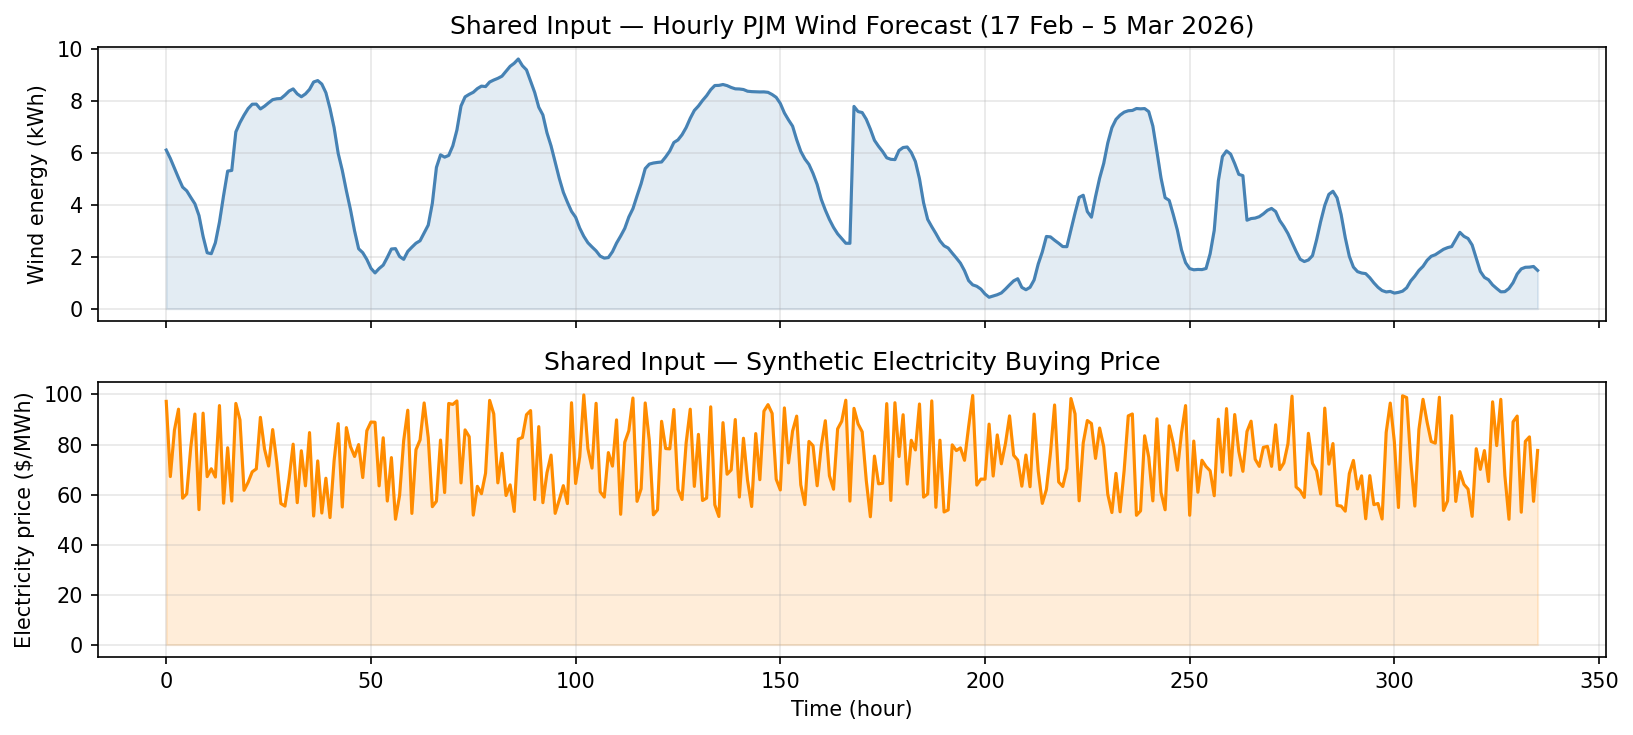

In [ ]:
# =============================================================================
# FIGURE 1 — Shared inputs: wind & price
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

ax1.plot(t_arr, lag_r_arr, color='steelblue')
ax1.fill_between(t_arr, lag_r_arr, alpha=0.15, color='steelblue')
ax1.set_ylabel('Wind energy (kWh)')
ax1.set_title('Shared Input — Hourly PJM Wind Forecast (17 Feb – 5 Mar 2026)')

ax2.plot(t_arr, lag_ab_arr, color='darkorange')
ax2.fill_between(t_arr, lag_ab_arr, alpha=0.15, color='darkorange')
ax2.set_ylabel('Electricity price ($/MWh)')
ax2.set_xlabel('Time (hour)')
ax2.set_title('Shared Input — Synthetic Electricity Buying Price')

plt.tight_layout()
plt.savefig('cmp_fig1_shared_inputs.png', bbox_inches='tight')
plt.show()

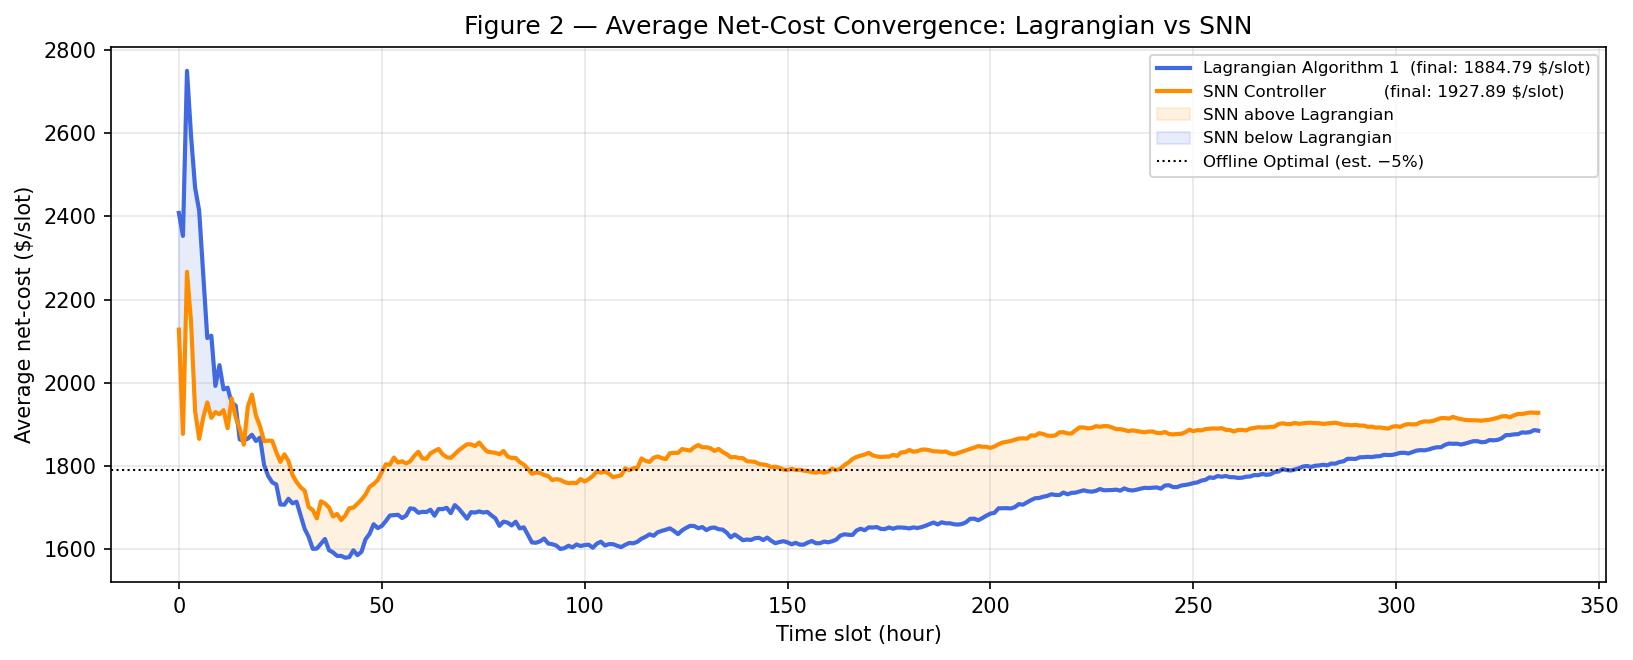

In [32]:
# =============================================================================
# FIGURE 2 — Average net-cost convergence  (key comparison)
# =============================================================================
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(t_arr, lag_avg_costs, color=LAG_C, linewidth=2,
        label=f'Lagrangian Algorithm 1  (final: {lag_avg_costs[-1]:.2f} $/slot)')
ax.plot(t_arr, snn_avg_costs, color=SNN_C, linewidth=2,
        label=f'SNN Controller           (final: {snn_avg_costs[-1]:.2f} $/slot)')

# Shade gap between controllers
ax.fill_between(t_arr, lag_avg_costs, snn_avg_costs,
                where=(snn_avg_costs >= lag_avg_costs),
                alpha=0.12, color=SNN_C, label='SNN above Lagrangian')
ax.fill_between(t_arr, lag_avg_costs, snn_avg_costs,
                where=(snn_avg_costs < lag_avg_costs),
                alpha=0.12, color=LAG_C, label='SNN below Lagrangian')

ax.axhline(min(lag_avg_costs[-1], snn_avg_costs[-1]) * 0.95,
           color='black', linestyle=':', linewidth=1, label='Offline Optimal (est. −5%)')

ax.set_xlabel('Time slot (hour)')
ax.set_ylabel('Average net-cost ($/slot)')
ax.set_title('Figure 2 — Average Net-Cost Convergence: Lagrangian vs SNN')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('cmp_fig2_avg_cost_convergence.png', bbox_inches='tight')
plt.show()

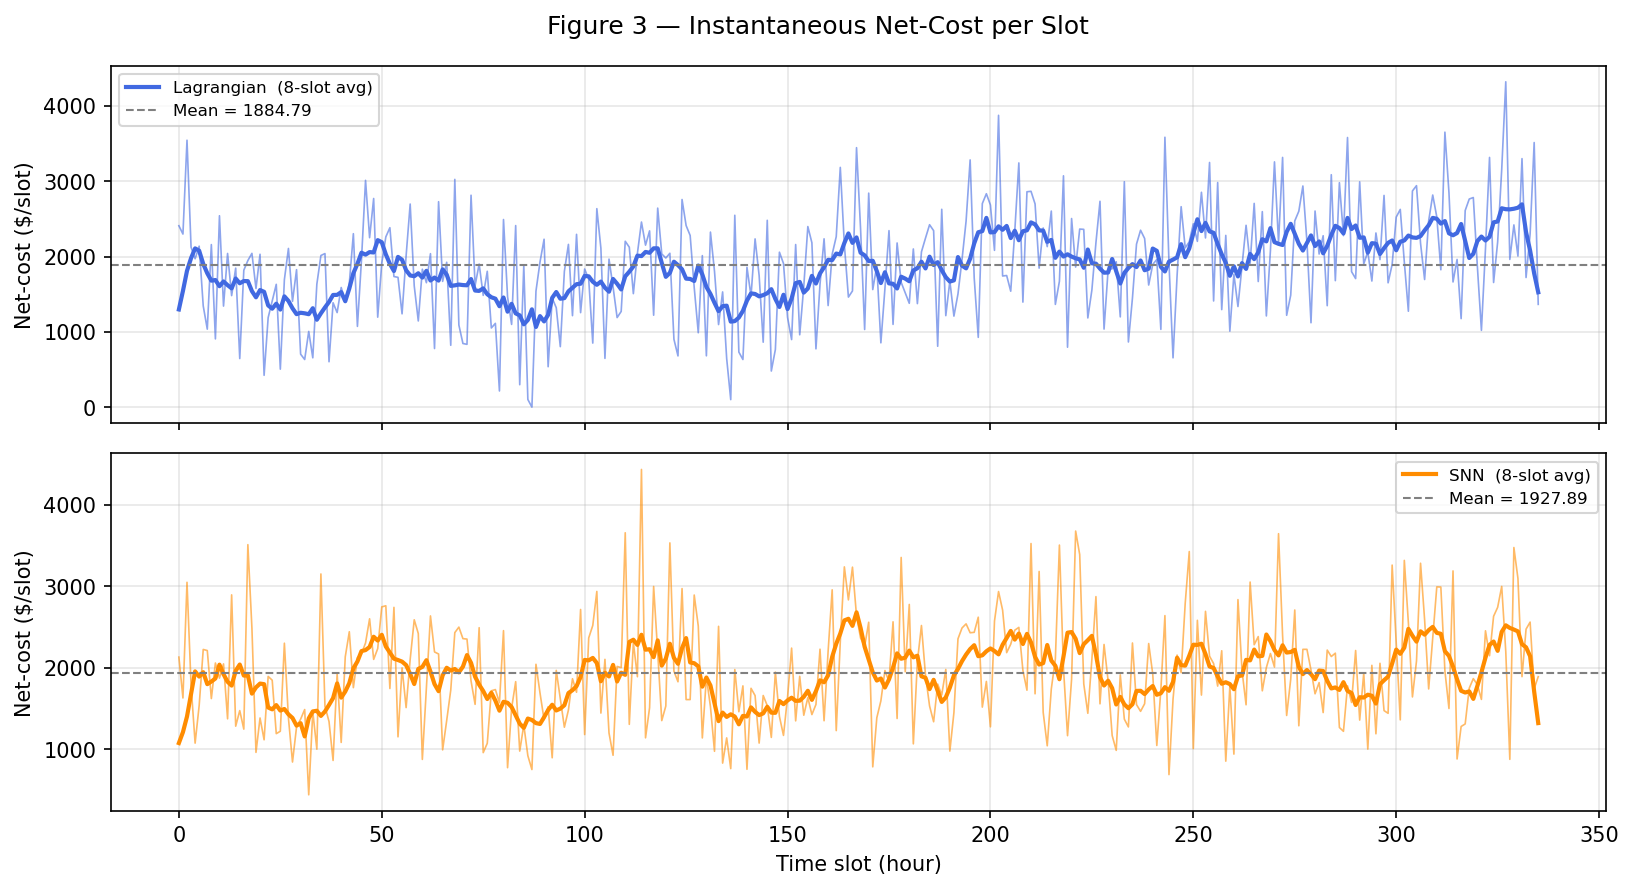

In [33]:
# =============================================================================
# FIGURE 3 — Instantaneous net-cost per slot
# =============================================================================
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

for ax, costs, color, label in zip(
    axes,
    [lag_cost_arr, snn_cost_arr],
    [LAG_C, SNN_C],
    ['Lagrangian', 'SNN']
):
    ax.plot(t_arr, costs, color=color, alpha=0.6, linewidth=0.8)
    window = max(1, T // 40)
    smooth = np.convolve(costs, np.ones(window)/window, mode='same')
    ax.plot(t_arr, smooth, color=color, linewidth=2,
            label=f'{label}  ({window}-slot avg)')
    ax.axhline(np.mean(costs), color='gray', linestyle='--',
               linewidth=1, label=f'Mean = {np.mean(costs):.2f}')
    ax.set_ylabel('Net-cost ($/slot)')
    ax.legend(fontsize=8)

axes[1].set_xlabel('Time slot (hour)')
fig.suptitle('Figure 3 — Instantaneous Net-Cost per Slot')
plt.tight_layout()
plt.savefig('cmp_fig3_instantaneous_cost.png', bbox_inches='tight')
plt.show()

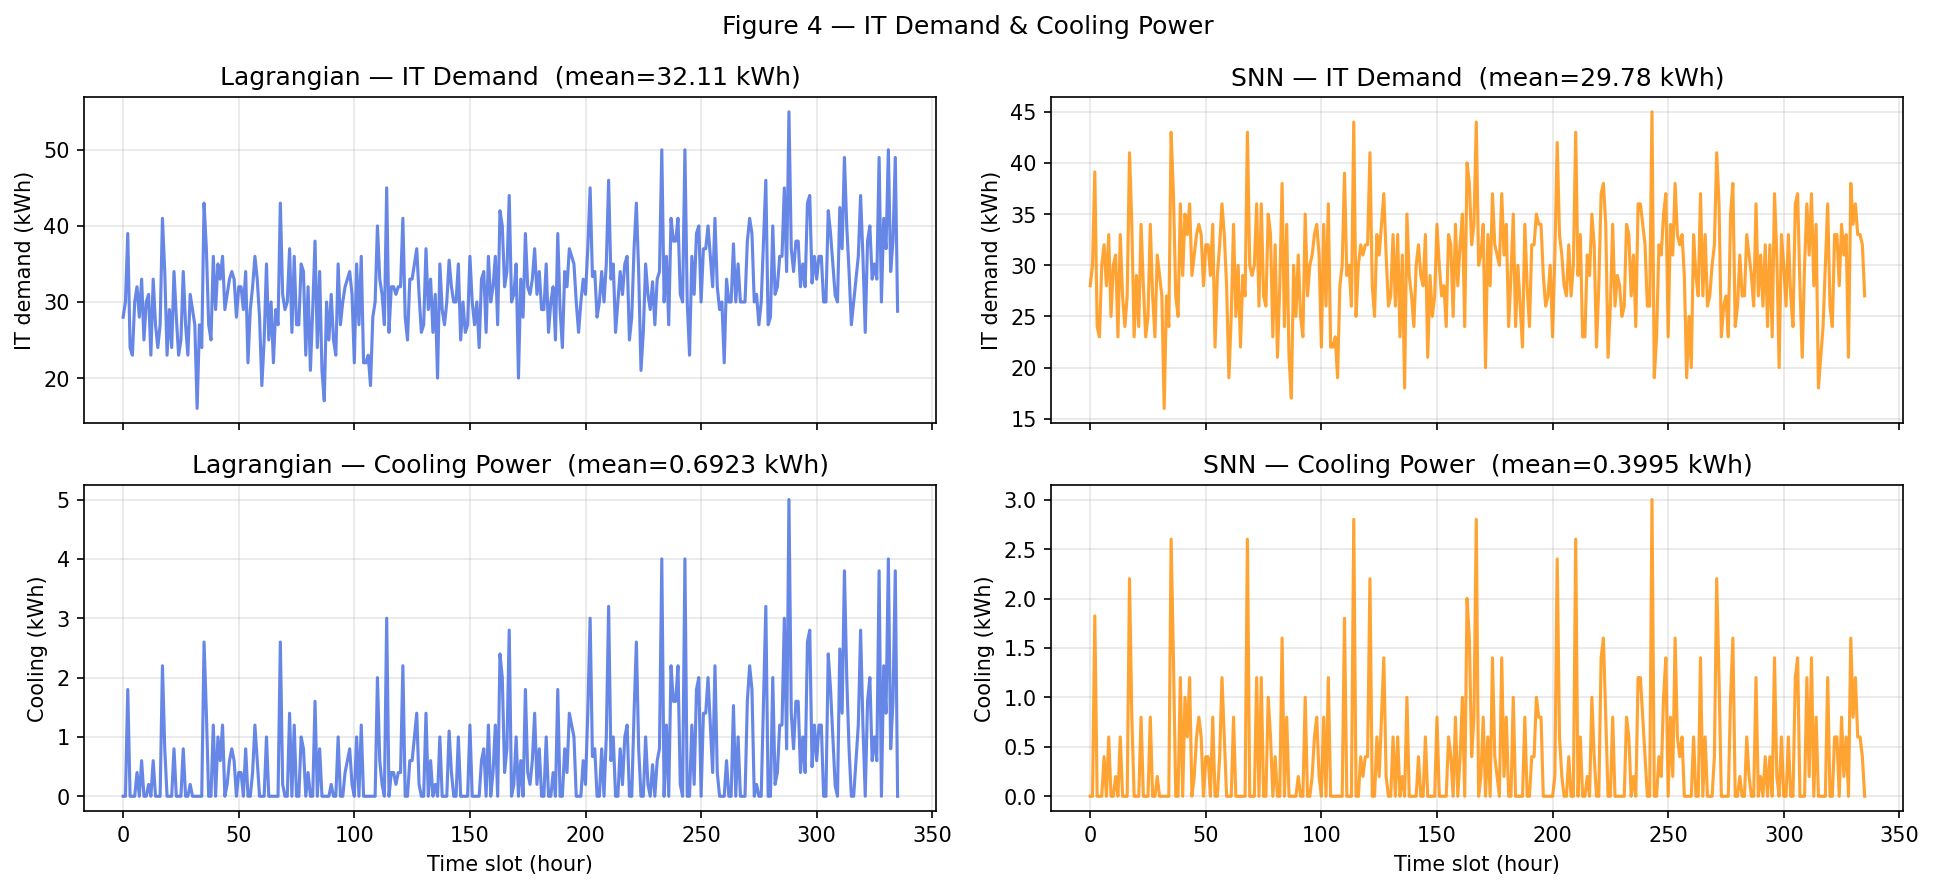

In [34]:
# =============================================================================
# FIGURE 4 — IT demand & cooling power
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True)

for col, (d_arr_, fd_arr_, color, label) in enumerate([
    (lag_d_arr, lag_fd_arr, LAG_C, 'Lagrangian'),
    (snn_d_arr, snn_fd_arr, SNN_C, 'SNN'),
]):
    axes[0, col].plot(t_arr, d_arr_, color=color, alpha=0.8)
    axes[0, col].set_title(f'{label} — IT Demand  (mean={np.mean(d_arr_):.2f} kWh)')
    axes[0, col].set_ylabel('IT demand (kWh)')

    axes[1, col].plot(t_arr, fd_arr_, color=color, alpha=0.8)
    axes[1, col].set_title(f'{label} — Cooling Power  (mean={np.mean(fd_arr_):.4f} kWh)')
    axes[1, col].set_ylabel('Cooling (kWh)')
    axes[1, col].set_xlabel('Time slot (hour)')

plt.suptitle('Figure 4 — IT Demand & Cooling Power')
plt.tight_layout()
plt.savefig('cmp_fig4_demand_cooling.png', bbox_inches='tight')
plt.show()

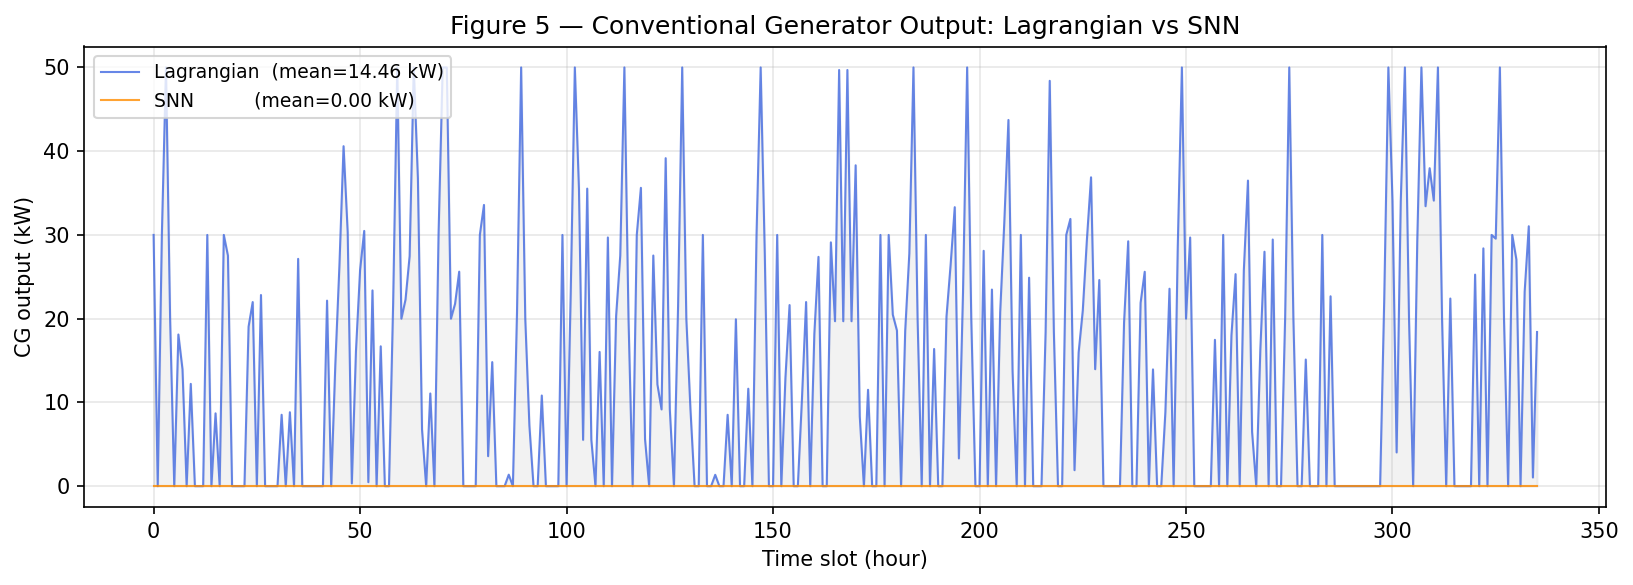

In [35]:
# =============================================================================
# FIGURE 5 — CG output overlay
# =============================================================================
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(t_arr, lag_Pc_arr, color=LAG_C, alpha=0.8, linewidth=1,
        label=f'Lagrangian  (mean={np.mean(lag_Pc_arr):.2f} kW)')
ax.plot(t_arr, snn_Pc_arr, color=SNN_C, alpha=0.8, linewidth=1,
        label=f'SNN          (mean={np.mean(snn_Pc_arr):.2f} kW)')
ax.fill_between(t_arr, lag_Pc_arr, snn_Pc_arr, alpha=0.1, color='gray')
ax.set_xlabel('Time slot (hour)')
ax.set_ylabel('CG output (kW)')
ax.set_title('Figure 5 — Conventional Generator Output: Lagrangian vs SNN')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('cmp_fig5_cg_output.png', bbox_inches='tight')
plt.show()

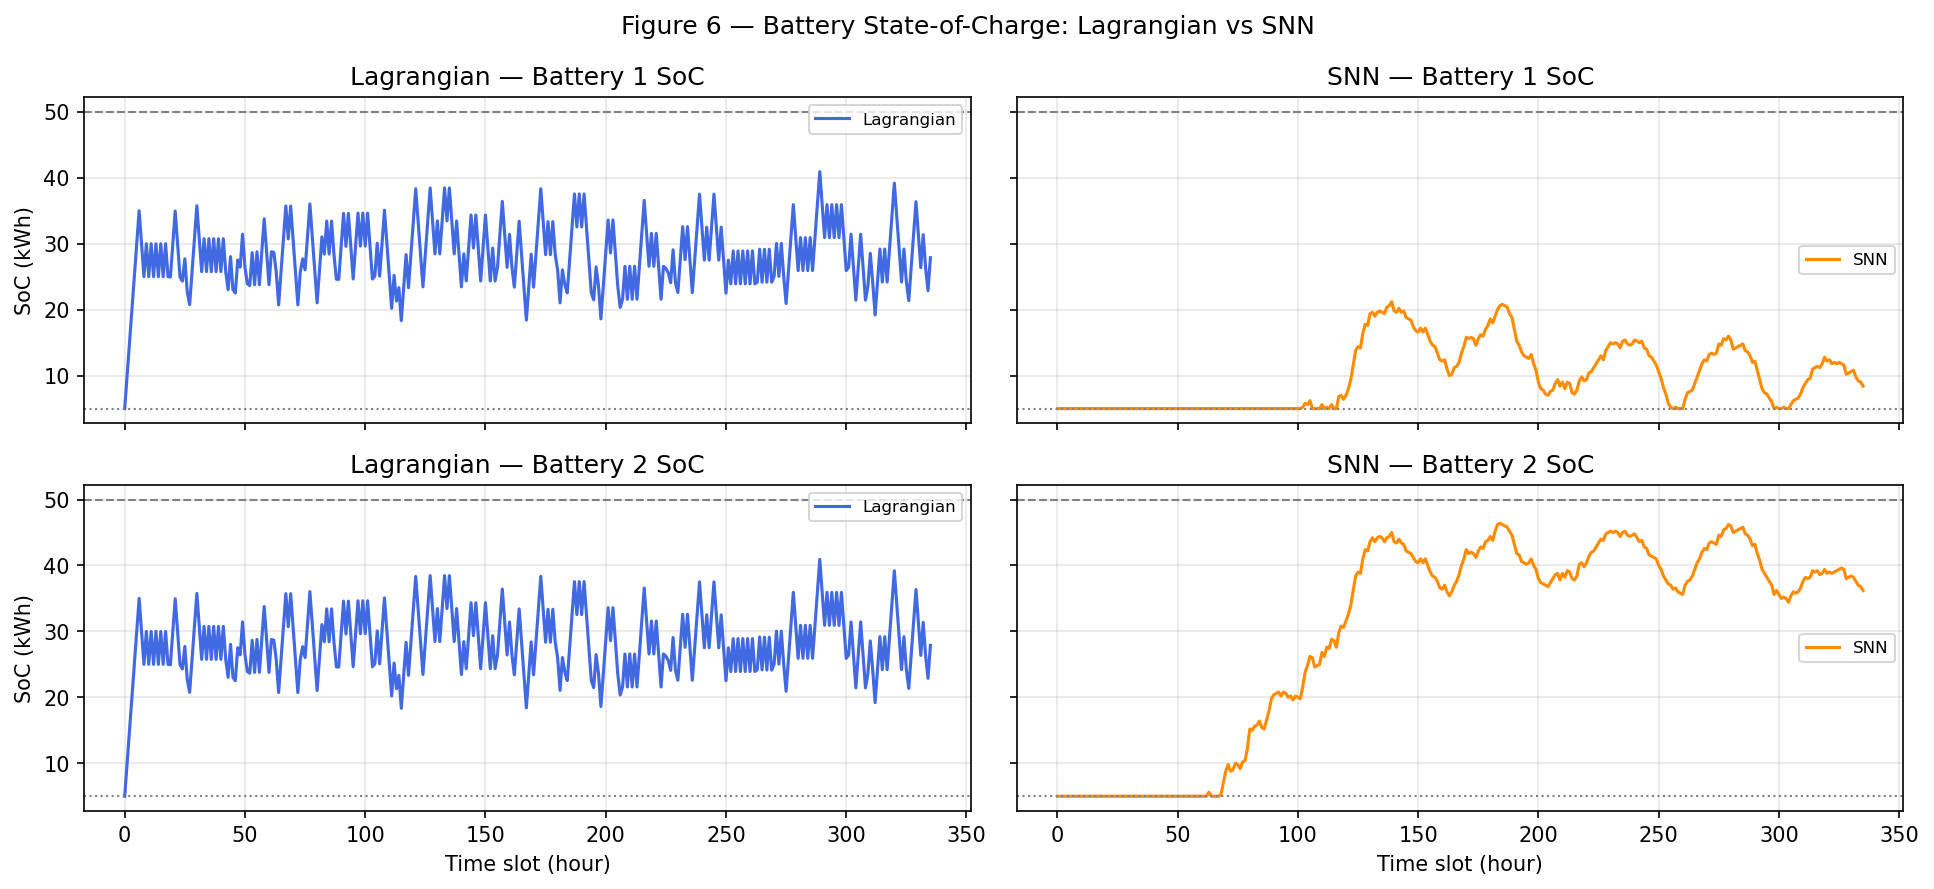

In [36]:
# =============================================================================
# FIGURE 6 — Battery SoC trajectories  (both controllers, both batteries)
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True, sharey=True)

for row, (soc_lag, soc_snn, bat_label) in enumerate([
    (lag_soc0, snn_soc0_arr, 'Battery 1'),
    (lag_soc1, snn_soc1_arr, 'Battery 2'),
]):
    axes[row, 0].plot(t_arr, soc_lag, color=LAG_C, label='Lagrangian')
    axes[row, 0].set_title(f'Lagrangian — {bat_label} SoC')
    axes[row, 0].set_ylabel('SoC (kWh)')

    axes[row, 1].plot(t_arr, soc_snn, color=SNN_C, label='SNN')
    axes[row, 1].set_title(f'SNN — {bat_label} SoC')

    for col in range(2):
        axes[row, col].axhline(batteries[0].C_min, color='gray', linestyle=':', linewidth=1)
        axes[row, col].axhline(batteries[0].C_max, color='gray', linestyle='--', linewidth=1)
        axes[row, col].legend(fontsize=8)

axes[1, 0].set_xlabel('Time slot (hour)')
axes[1, 1].set_xlabel('Time slot (hour)')
fig.suptitle('Figure 6 — Battery State-of-Charge: Lagrangian vs SNN')
plt.tight_layout()
plt.savefig('cmp_fig6_battery_soc.png', bbox_inches='tight')
plt.show()

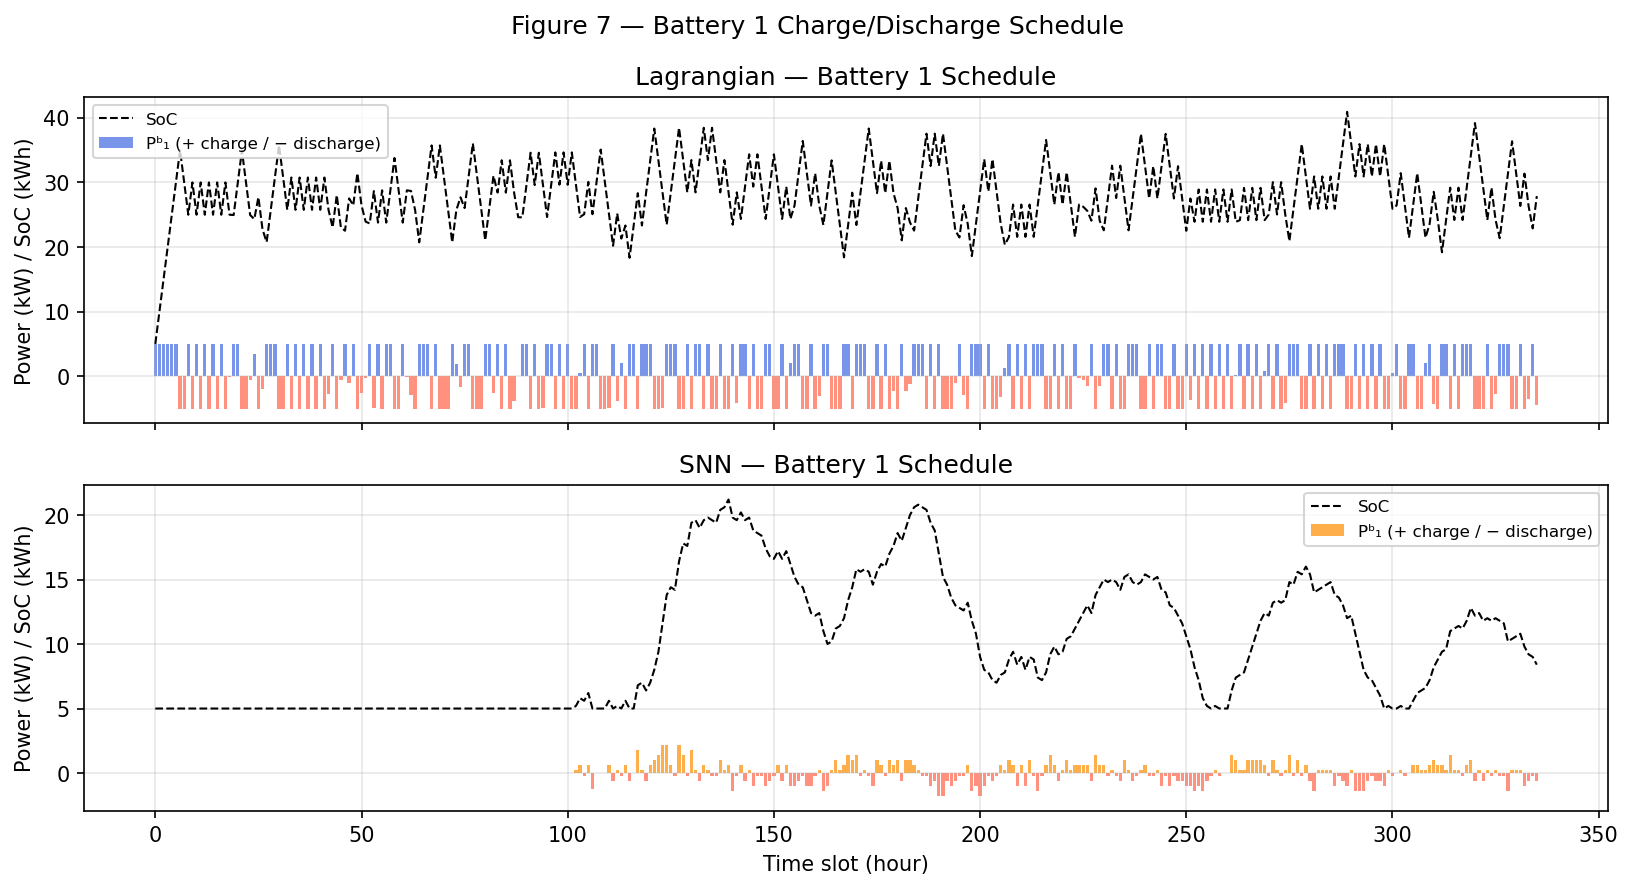

In [37]:
# =============================================================================
# FIGURE 7 — Battery 1 charging schedule overlay
# =============================================================================
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

for ax, pb_arr, soc_arr, color, label in zip(
    axes,
    [lag_pb0_arr, snn_pb0_arr],
    [lag_soc0, snn_soc0_arr],
    [LAG_C, SNN_C],
    ['Lagrangian', 'SNN']
):
    ax.bar(t_arr, pb_arr,
           color=np.where(pb_arr >= 0, color, 'tomato'),
           width=0.8, alpha=0.7, label='Pᵇ₁ (+ charge / − discharge)')
    ax.plot(t_arr, soc_arr, color='black', linewidth=1, linestyle='--',
            label='SoC')
    ax.set_ylabel('Power (kW) / SoC (kWh)')
    ax.set_title(f'{label} — Battery 1 Schedule')
    ax.legend(fontsize=8)

axes[1].set_xlabel('Time slot (hour)')
fig.suptitle('Figure 7 — Battery 1 Charge/Discharge Schedule')
plt.tight_layout()
plt.savefig('cmp_fig7_battery_schedule.png', bbox_inches='tight')
plt.show()

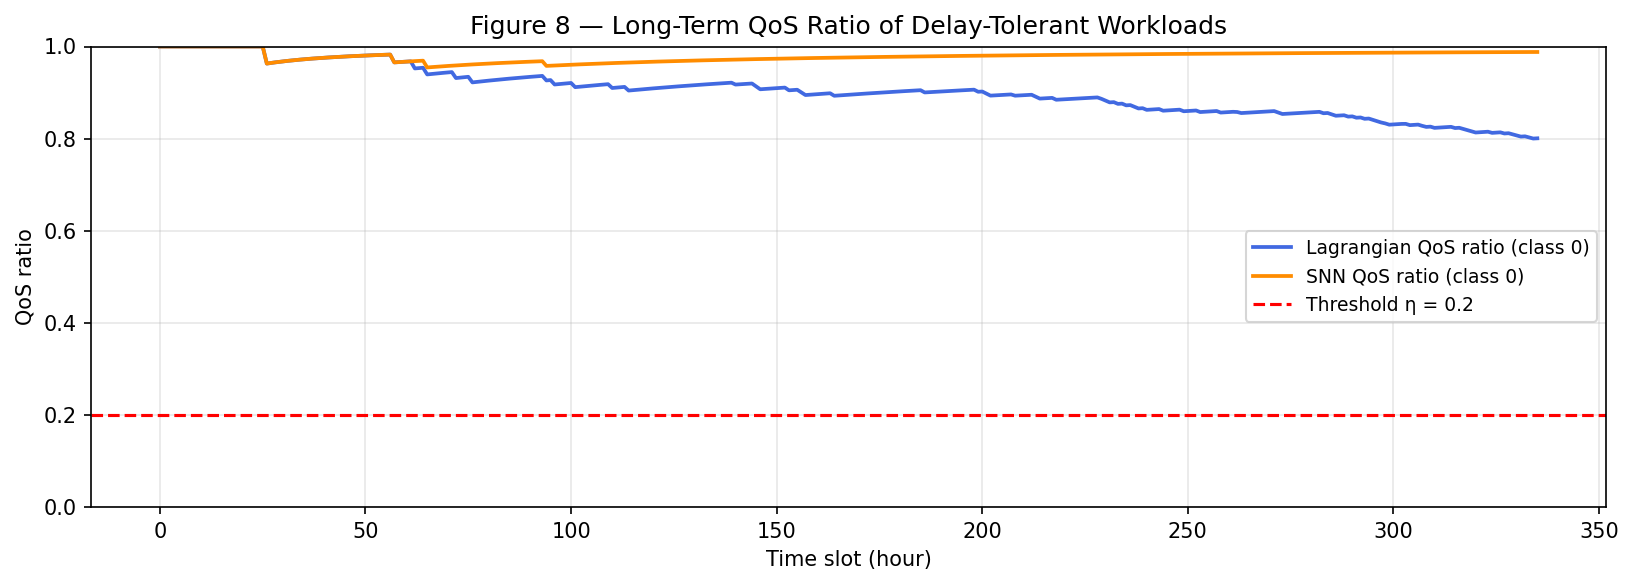

In [38]:
# =============================================================================
# FIGURE 8 — QoS ratio of delay-tolerant workload (class 0)
# =============================================================================
w_check_0 = w_check_seq[:, 0]

def qos_running_avg(w_alloc):
    pending = (w_check_0 - w_alloc) / np.maximum(w_check_0, 1e-9)
    return np.cumsum(pending) / (t_arr + 1)

lag_qos = qos_running_avg(lag_w_arrs[0])
snn_qos = qos_running_avg(snn_w_arrs[0])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_arr, lag_qos, color=LAG_C, linewidth=1.8,
        label='Lagrangian QoS ratio (class 0)')
ax.plot(t_arr, snn_qos, color=SNN_C, linewidth=1.8,
        label='SNN QoS ratio (class 0)')
ax.axhline(params.eta, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold η = {params.eta}')
ax.set_ylim(0, 1)
ax.set_xlabel('Time slot (hour)')
ax.set_ylabel('QoS ratio')
ax.set_title('Figure 8 — Long-Term QoS Ratio of Delay-Tolerant Workloads')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('cmp_fig8_qos_ratio.png', bbox_inches='tight')
plt.show()

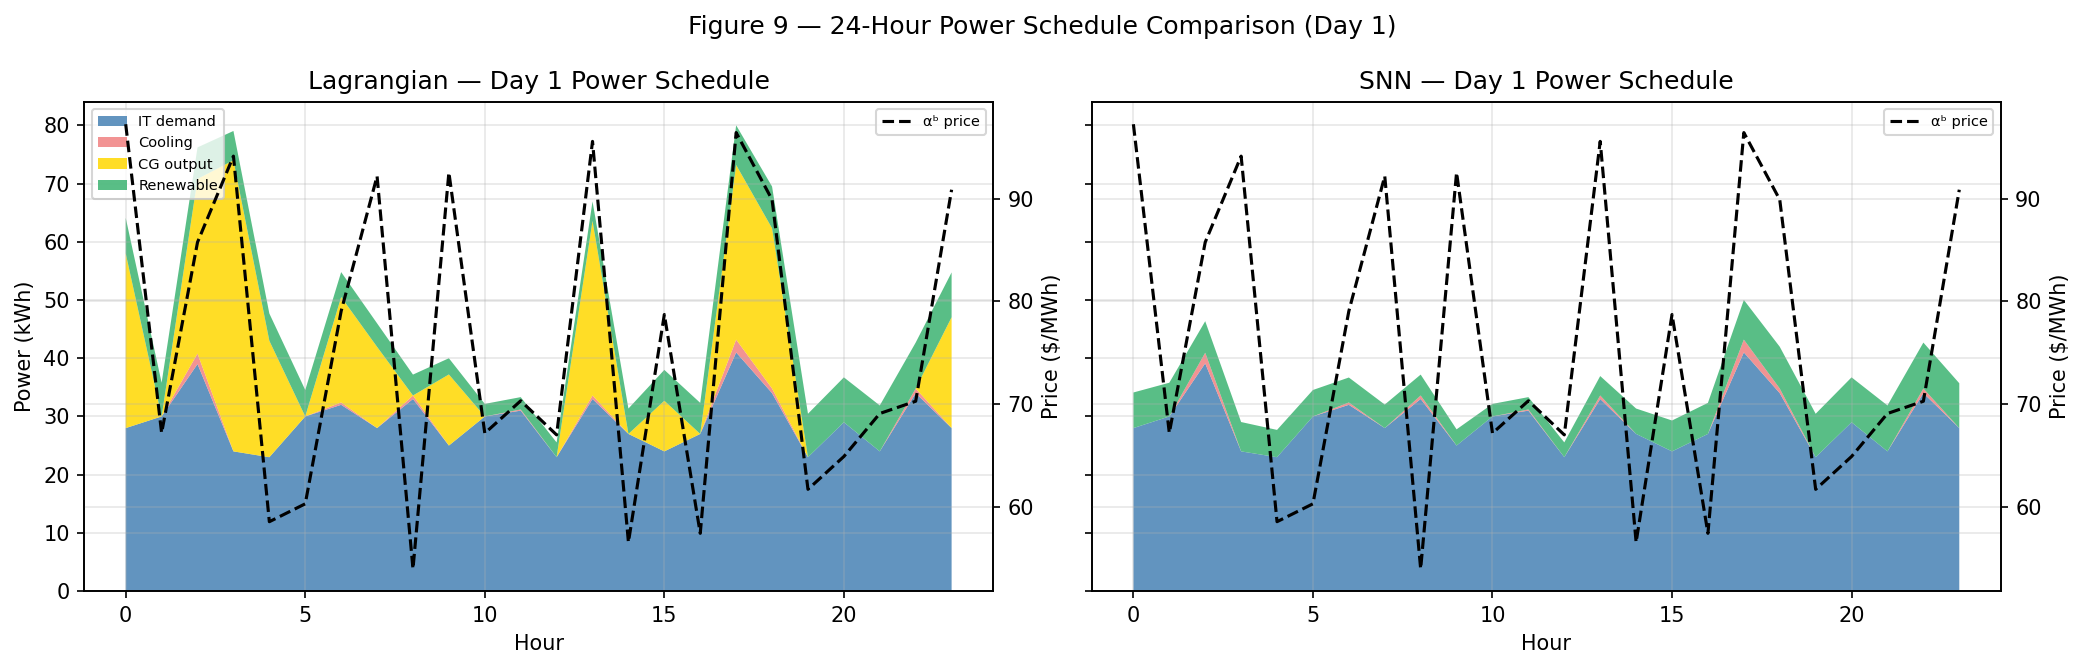

In [39]:
# =============================================================================
# FIGURE 9 — 24-hour stacked power schedule  (Day 1)
# =============================================================================
idx   = slice(0, 24)
hours = np.arange(24)
COLORS = ['steelblue', 'lightcoral', 'gold', 'mediumseagreen']
LABELS = ['IT demand', 'Cooling', 'CG output', 'Renewable']

fig, (ax_l, ax_s) = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, d_, fd_, Pc_, r_, ab_, title in [
    (ax_l, lag_d_arr, lag_fd_arr, lag_Pc_arr, lag_r_arr, lag_ab_arr, 'Lagrangian'),
    (ax_s, snn_d_arr, snn_fd_arr, snn_Pc_arr, snn_r_arr, lag_ab_arr, 'SNN'),
]:
    ax.stackplot(hours,
                 d_[idx], fd_[idx], Pc_[idx], r_[idx],
                 labels=LABELS, colors=COLORS, alpha=0.85)
    ax2 = ax.twinx()
    ax2.plot(hours, ab_[idx], color='black', linestyle='--',
             linewidth=1.5, label='αᵇ price')
    ax2.set_ylabel('Price ($/MWh)')
    ax2.legend(loc='upper right', fontsize=7)
    ax.set_title(f'{title} — Day 1 Power Schedule')
    ax.set_xlabel('Hour')

ax_l.set_ylabel('Power (kWh)')
ax_l.legend(loc='upper left', fontsize=7)
fig.suptitle('Figure 9 — 24-Hour Power Schedule Comparison (Day 1)')
plt.tight_layout()
plt.savefig('cmp_fig9_power_schedule_24h.png', bbox_inches='tight')
plt.show()

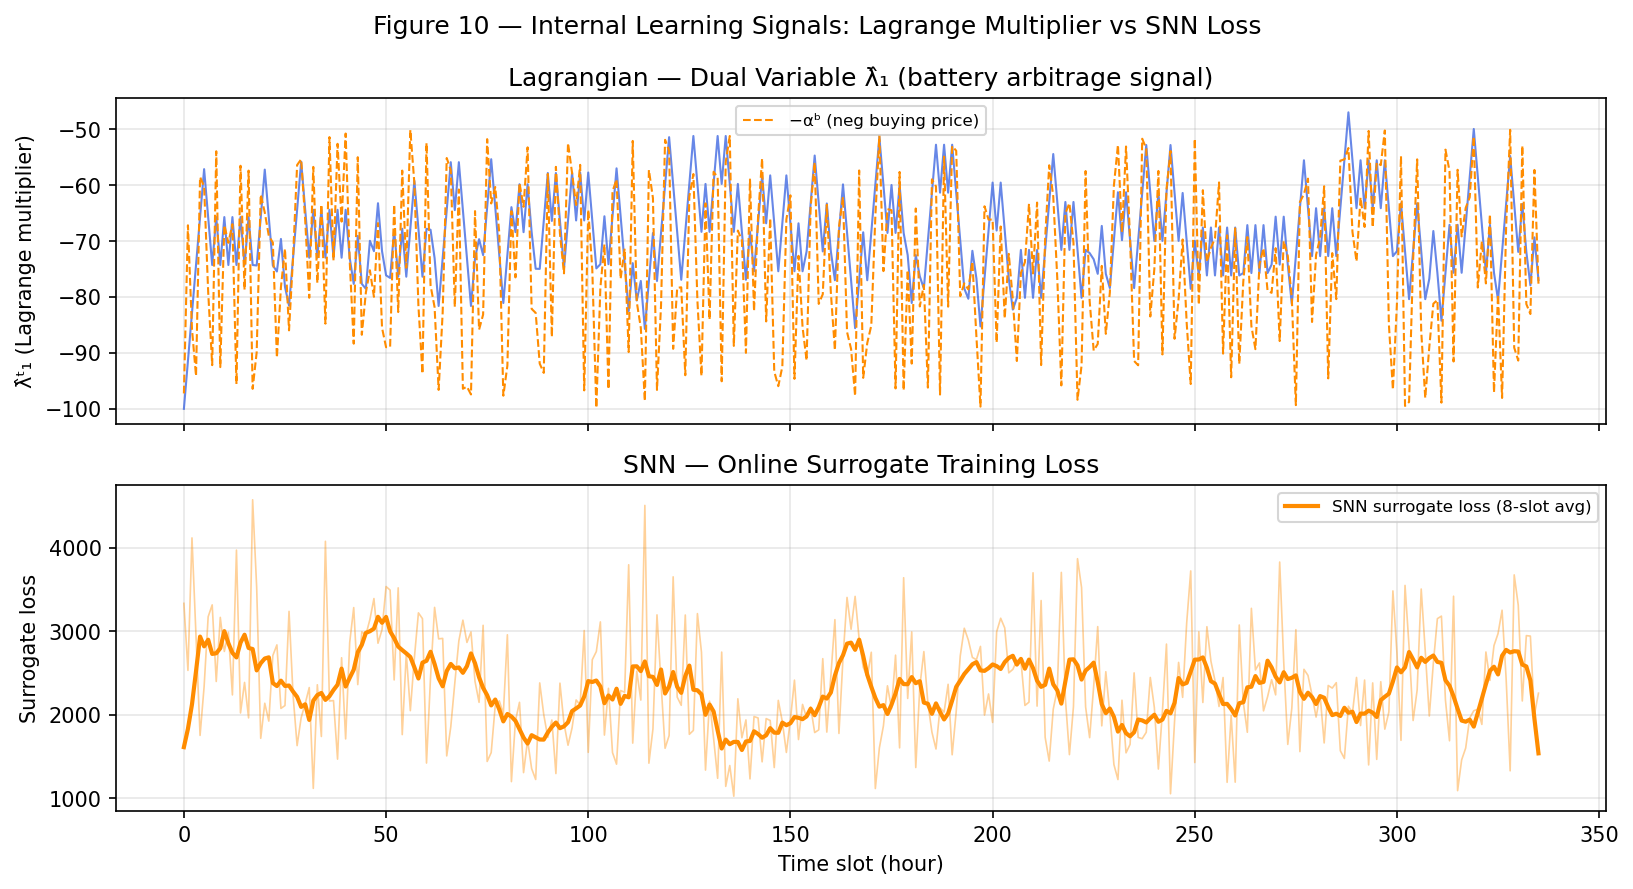

In [40]:
# =============================================================================
# FIGURE 10 — Lagrange multiplier (λ̂) vs SNN surrogate loss
#             These are the respective internal 'learning signals' of each controller
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax1.plot(t_arr, lag_lam_arr, color=LAG_C, linewidth=1, alpha=0.8)
ax1.plot(t_arr, -lag_ab_arr, color='darkorange', linestyle='--',
         linewidth=1, label='−αᵇ (neg buying price)')
ax1.set_ylabel('λ̂ᵗ₁ (Lagrange multiplier)')
ax1.set_title('Lagrangian — Dual Variable λ̂₁ (battery arbitrage signal)')
ax1.legend(fontsize=8)

window = max(1, T // 40)
loss_smooth = np.convolve(snn_loss_arr, np.ones(window)/window, mode='same')
ax2.plot(t_arr, snn_loss_arr, color=SNN_C, alpha=0.4, linewidth=0.8)
ax2.plot(t_arr, loss_smooth,  color=SNN_C, linewidth=2,
         label=f'SNN surrogate loss ({window}-slot avg)')
ax2.set_ylabel('Surrogate loss')
ax2.set_xlabel('Time slot (hour)')
ax2.set_title('SNN — Online Surrogate Training Loss')
ax2.legend(fontsize=8)

fig.suptitle('Figure 10 — Internal Learning Signals: Lagrange Multiplier vs SNN Loss')
plt.tight_layout()
plt.savefig('cmp_fig10_learning_signals.png', bbox_inches='tight')
plt.show()

In [ ]:
# =============================================================================
# FIGURE 11 — Cost distribution  (histogram + KDE)
# =============================================================================
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(9, 4))

for costs, color, label in [
    (lag_cost_arr, LAG_C, 'Lagrangian'),
    (snn_cost_arr, SNN_C, 'SNN'),
]:
    ax.hist(costs, bins=40, density=True, alpha=0.3, color=color)
    kde = gaussian_kde(costs)
    xs  = np.linspace(costs.min(), costs.max(), 400)
    ax.plot(xs, kde(xs), color=color, linewidth=2,
            label=f'{label}  μ={np.mean(costs):.2f}  σ={np.std(costs):.2f}')
    ax.axvline(np.mean(costs), color=color, linestyle='--', linewidth=1)

ax.set_xlabel('Net-cost ($/slot)')
ax.set_ylabel('Density')
ax.set_title('Figure 11 — Net-Cost Distribution: Lagrangian vs SNN')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('cmp_fig11_cost_distribution.png', bbox_inches='tight')
plt.show()

In [ ]:
# =============================================================================
# FIGURE 12 — Renewable utilisation: how much wind was actually used
#             (P_in - P_c) / r  → fraction of renewable absorbed each slot
# =============================================================================
def renewable_util(records_, Pc_arr_, r_arr_):
    pb_sum = np.array([sum(records_[t][f'p_b_{n}'] for n in range(2))
                       for t in range(T)])
    P_in = Pc_arr_ + r_arr_ - np.clip(pb_sum, None, 0)
    # fraction of available renewable absorbed = min(r, P_in) / r
    absorbed = np.clip(P_in, 0, r_arr_)
    return absorbed / np.maximum(r_arr_, 1e-9)

lag_util = renewable_util(lag_records, lag_Pc_arr, lag_r_arr)
snn_util = renewable_util(snn_records, snn_Pc_arr, snn_r_arr)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_arr, np.cumsum(lag_util) / (t_arr + 1),
        color=LAG_C, linewidth=2,
        label=f'Lagrangian  (final avg={lag_util.mean():.2%})')
ax.plot(t_arr, np.cumsum(snn_util) / (t_arr + 1),
        color=SNN_C, linewidth=2,
        label=f'SNN          (final avg={snn_util.mean():.2%})')
ax.set_ylim(0, 1.05)
ax.set_xlabel('Time slot (hour)')
ax.set_ylabel('Cumulative avg renewable utilisation')
ax.set_title('Figure 12 — Renewable Energy Utilisation: Lagrangian vs SNN')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('cmp_fig12_renewable_utilisation.png', bbox_inches='tight')
plt.show()

---
## Architecture & Design Summary

| Metric | Lagrangian (Alg 1) | SNN Controller |
|---|---|---|
| **Solver** | CVXPY / SciPy LP | Forward pass + Adam SGD |
| **Per-slot complexity** | O(solve time, ~ms–s) | O(T_steps × layers, fixed μs) |
| **Constraint handling** | Hard (solver) | Physical clipping + QoS penalty |
| **Adaptability** | Fixed μ, converging multipliers | Continuously adapts weights |
| **State encoding** | Raw scalars | Bernoulli rate-coded spikes |
| **Learning signal** | Lyapunov drift-plus-penalty | Differentiable surrogate net-cost |
| **Theoretical guarantee** | O(1/T) cost gap from optimal | None (empirical only) |
| **Hardware friendliness** | Standard CPU/GPU | Neuromorphic chip compatible |

### Key design choices for the SNN
- **Rate coding** maps each normalised feature to a Bernoulli spike probability over 25 time steps, giving a natural analogue-to-spike interface without hand-tuning.
- **Surrogate gradient** (`fast_sigmoid`, slope=25) enables end-to-end backprop through the non-differentiable LIF spike threshold.
- **Online normalisation** handles non-stationary price and demand distributions without a separate pre-training phase, keeping the SNN comparable to the online Lagrangian baseline.
- **Hard clipping at decode** enforces physical constraints (SoC limits, ramp rates) deterministically, preventing infeasible actions regardless of what the network outputs.